# 11. BMI Classification ML
**피처**: Gender, Height, Weight (BMI 파생 피처 없음 — 모델이 직접 비율 관계 학습)
**타겟**: Index (0~5, 비만 6단계 분류)
**목차**: EDA → 전처리 → 모델링 → 교차검증 → 성능분석 → 시각화

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)

# 한글 폰트
font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 출력 경로
OUT = '../output/'

# 클래스 레이블
INDEX_NAMES = {
    0: 'Extremely\nWeak',
    1: 'Weak',
    2: 'Normal',
    3: 'Overweight',
    4: 'Obesity',
    5: 'Extreme\nObesity'
}
LABEL_NAMES = ['Extremely Weak','Weak','Normal','Overweight','Obesity','Extreme Obesity']
COLORS = ['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
df = pd.read_csv('../bmi_dataset.csv')
print(f'Shape: {df.shape}')
print(f'결측치: {df.isnull().sum().sum()}개')
print(f'중복행: {df.duplicated().sum()}개')
print()
print('--- 기술통계 ---')
display(df.describe())
print()
print('--- 상위 5행 ---')
display(df.head())

Shape: (500, 4)
결측치: 0개
중복행: 11개

--- 기술통계 ---


,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000



--- 상위 5행 ---


,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


## 2. EDA (탐색적 데이터 분석)

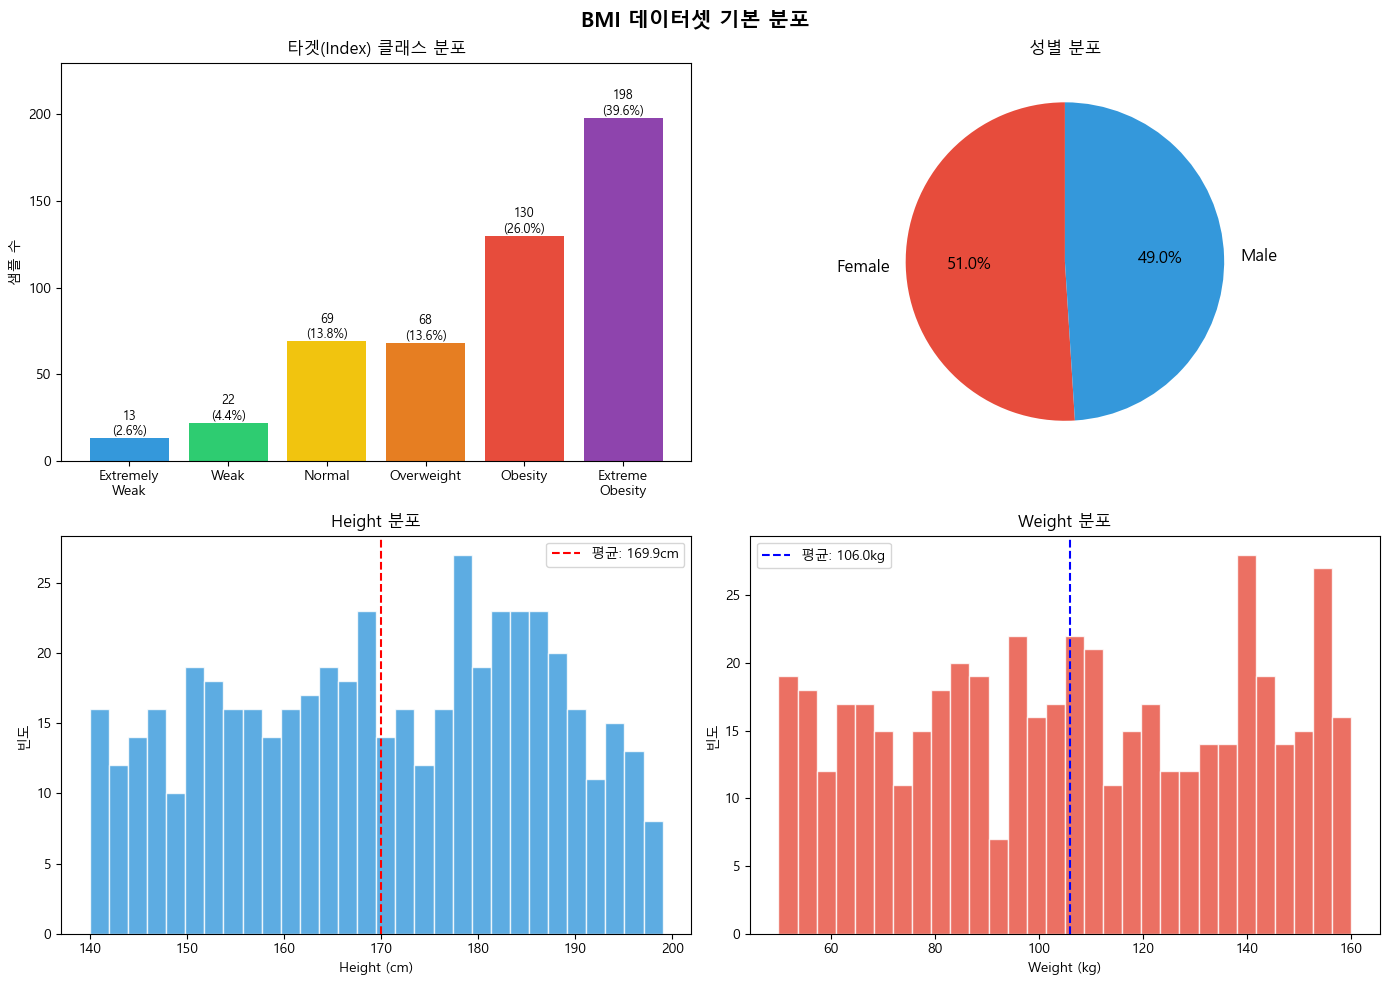

저장: 01_eda_distribution.png


In [3]:
# --- [차트 1] 클래스 분포 + 성별 분포 + Height/Weight 전체 히스토그램 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('BMI 데이터셋 기본 분포', fontsize=15, fontweight='bold')

# 1-1. Index 클래스 분포
counts = df['Index'].value_counts().sort_index()
bars = axes[0,0].bar([INDEX_NAMES[i] for i in counts.index], counts.values, color=COLORS)
for bar, v in zip(bars, counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+2, f'{v}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=9)
axes[0,0].set_title('타겟(Index) 클래스 분포', fontsize=12)
axes[0,0].set_ylabel('샘플 수')
axes[0,0].set_ylim(0, 230)

# 1-2. 성별 분포
gender_counts = df['Gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index,
              autopct='%1.1f%%', colors=['#e74c3c','#3498db'],
              startangle=90, textprops={'fontsize':12})
axes[0,1].set_title('성별 분포', fontsize=12)

# 1-3. Height 분포
axes[1,0].hist(df['Height'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[1,0].axvline(df['Height'].mean(), color='red', linestyle='--',
                  label=f'평균: {df["Height"].mean():.1f}cm')
axes[1,0].set_title('Height 분포', fontsize=12)
axes[1,0].set_xlabel('Height (cm)')
axes[1,0].set_ylabel('빈도')
axes[1,0].legend()

# 1-4. Weight 분포
axes[1,1].hist(df['Weight'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1,1].axvline(df['Weight'].mean(), color='blue', linestyle='--',
                  label=f'평균: {df["Weight"].mean():.1f}kg')
axes[1,1].set_title('Weight 분포', fontsize=12)
axes[1,1].set_xlabel('Weight (kg)')
axes[1,1].set_ylabel('빈도')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{OUT}01_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_eda_distribution.png')

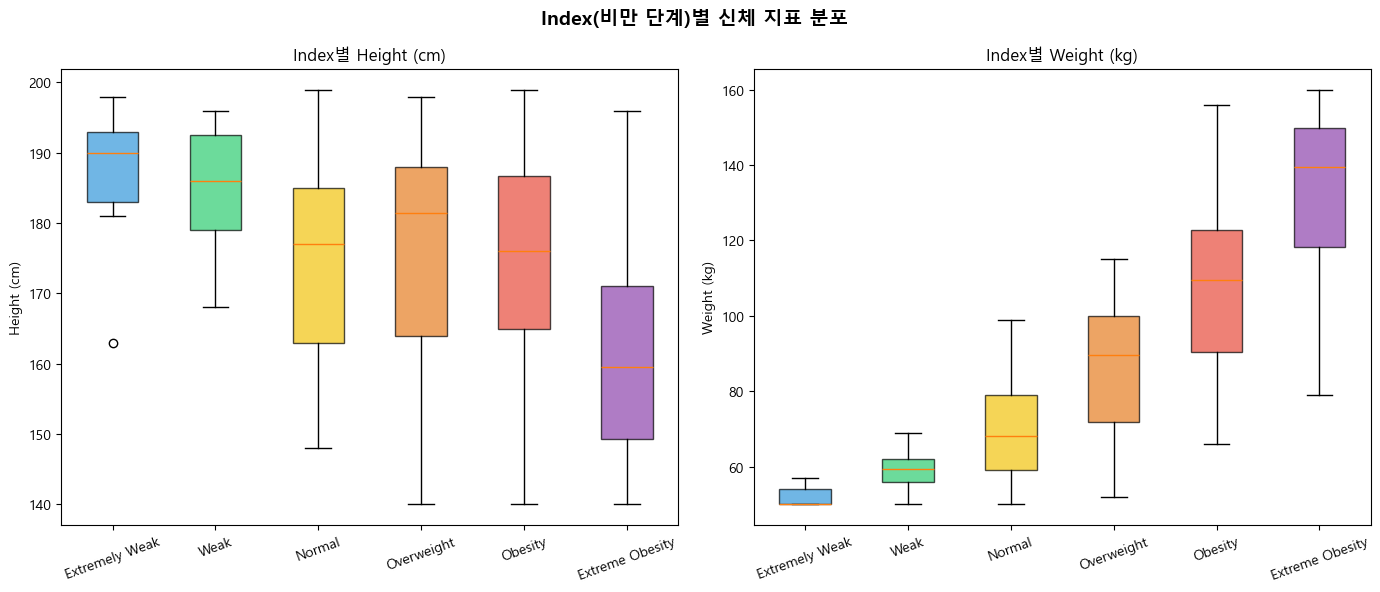

저장: 02_eda_boxplot.png


In [4]:
# --- [차트 2] Index별 Height/Weight 박스플롯 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Index(비만 단계)별 신체 지표 분포', fontsize=14, fontweight='bold')

# 박스플롯 데이터 준비
height_by_index = [df[df['Index']==i]['Height'].values for i in range(6)]
weight_by_index = [df[df['Index']==i]['Weight'].values for i in range(6)]
tick_labels = [LABEL_NAMES[i] for i in range(6)]

bp1 = axes[0].boxplot(height_by_index, labels=tick_labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Index별 Height (cm)', fontsize=12)
axes[0].set_ylabel('Height (cm)')
axes[0].tick_params(axis='x', rotation=20)

bp2 = axes[1].boxplot(weight_by_index, labels=tick_labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Index별 Weight (kg)', fontsize=12)
axes[1].set_ylabel('Weight (kg)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{OUT}02_eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_eda_boxplot.png')

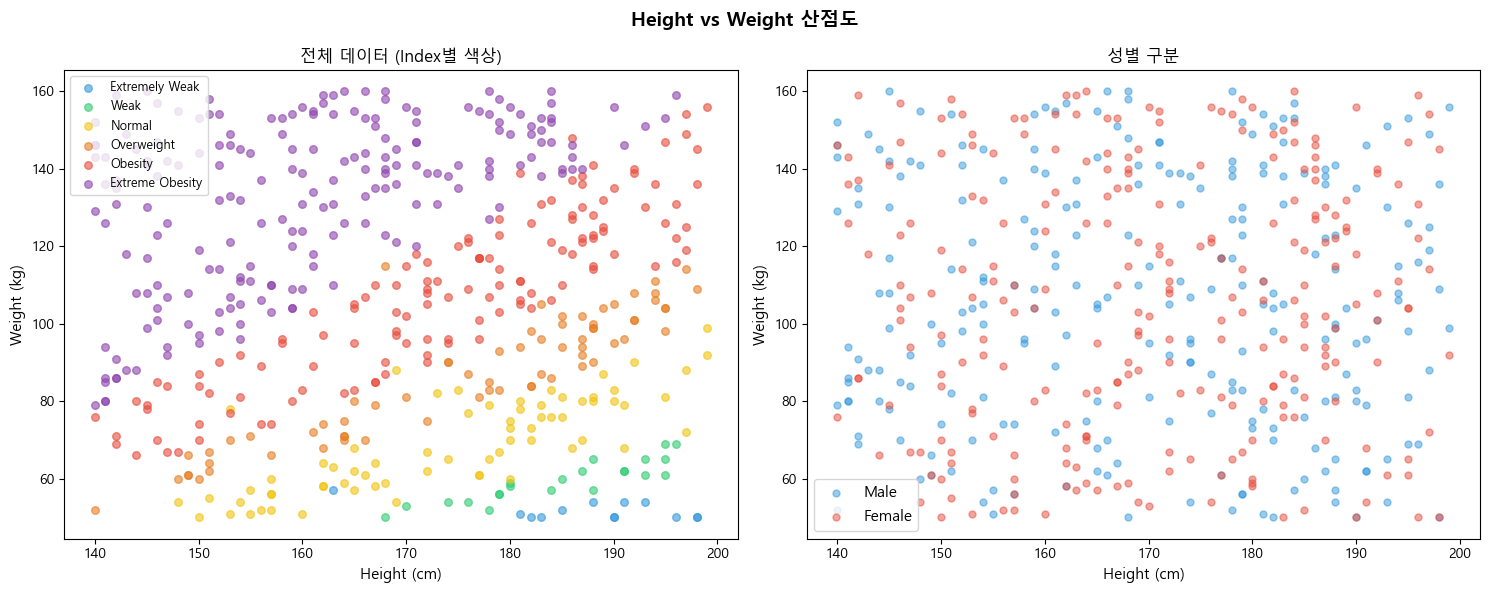

저장: 03_eda_scatter.png


In [5]:
# --- [차트 3] Height vs Weight 산점도 (Index별 색상) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Height vs Weight 산점도', fontsize=14, fontweight='bold')

# 전체 산점도
for idx in range(6):
    mask = df['Index'] == idx
    axes[0].scatter(df[mask]['Height'], df[mask]['Weight'],
                    c=COLORS[idx], label=LABEL_NAMES[idx], alpha=0.6, s=30)
axes[0].set_xlabel('Height (cm)', fontsize=11)
axes[0].set_ylabel('Weight (kg)', fontsize=11)
axes[0].set_title('전체 데이터 (Index별 색상)', fontsize=12)
axes[0].legend(fontsize=9, loc='upper left')

# 성별 구분 산점도
male   = df[df['Gender']=='Male']
female = df[df['Gender']=='Female']
axes[1].scatter(male['Height'],   male['Weight'],   c='#3498db', label='Male',   alpha=0.5, s=25)
axes[1].scatter(female['Height'], female['Weight'], c='#e74c3c', label='Female', alpha=0.5, s=25)
axes[1].set_xlabel('Height (cm)', fontsize=11)
axes[1].set_ylabel('Weight (kg)', fontsize=11)
axes[1].set_title('성별 구분', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUT}03_eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_eda_scatter.png')

## 3. 전처리

In [6]:
# Gender 인코딩 (Female=0, Male=1)
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])

# BMI 파생 피처 없이 3개 원본 피처만 사용
X = df[['Gender_enc', 'Height', 'Weight']]
y = df['Index']

# 8:2 분리, stratify로 클래스 비율 보존
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 (거리/확률 기반 모델에 적용)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # train 기준으로 fit
X_test_sc  = scaler.transform(X_test)       # test는 transform만

print('=== 전처리 완료 ===')
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print()
print('Train Index 분포:')
print(pd.Series(y_train).value_counts().sort_index())
print()
print('Test Index 분포:')
print(pd.Series(y_test).value_counts().sort_index())

=== 전처리 완료 ===
Train: (400, 3)  |  Test: (100, 3)

Train Index 분포:
Index
0     10
1     18
2     55
3     54
4    104
5    159
Name: count, dtype: int64

Test Index 분포:
Index
0     3
1     4
2    14
3    14
4    26
5    39
Name: count, dtype: int64


## 4. 모델링 — 6개 알고리즘 비교

In [7]:
# class_weight='balanced': 소수 클래스(Index 0,1)에 더 높은 가중치 부여
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), True),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42), False),
    'SVM (RBF)':           (SVC(kernel='rbf', C=10, class_weight='balanced', probability=True, random_state=42), True),
    'KNN':                 (KNeighborsClassifier(n_neighbors=7), True),
}

# 5-Fold 층화 교차검증
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'f1_weighted']

results = {}
print(f'{"모델":<22} | {"Test Acc":>8} | {"Test F1(M)":>10} | {"CV F1(M)":>9} | {"CV F1(W)":>9}')
print('-' * 70)

for name, (model, use_scale) in models.items():
    Xtr = X_train_sc if use_scale else X_train
    Xte = X_test_sc  if use_scale else X_test
    Xall = scaler.transform(X) if use_scale else X

    # 학습 및 테스트셋 예측
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    # 교차검증
    cv_res = cross_validate(model, Xall, y, cv=cv, scoring=scoring, n_jobs=-1)

    results[name] = {
        'model': model,
        'use_scale': use_scale,
        'y_pred': y_pred,
        'test_acc':      accuracy_score(y_test, y_pred),
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'test_f1_w':     f1_score(y_test, y_pred, average='weighted'),
        'cv_f1_macro':   cv_res['test_f1_macro'].mean(),
        'cv_f1_macro_std': cv_res['test_f1_macro'].std(),
        'cv_f1_w':       cv_res['test_f1_weighted'].mean(),
        'cv_acc':        cv_res['test_accuracy'].mean(),
        'cv_raw': cv_res
    }
    r = results[name]
    print(f'{name:<22} | {r["test_acc"]:>8.4f} | {r["test_f1_macro"]:>10.4f} | '
          f'{r["cv_f1_macro"]:>8.4f} | {r["cv_f1_w"]:>9.4f}')

모델                     | Test Acc | Test F1(M) |  CV F1(M) |  CV F1(W)
----------------------------------------------------------------------


Logistic Regression    |   0.8700 |     0.7601 |   0.7173 |    0.8370


Decision Tree          |   0.8300 |     0.7522 |   0.8003 |    0.8450


Random Forest          |   0.8200 |     0.7685 |   0.8125 |    0.8683


Gradient Boosting      |   0.8300 |     0.8007 |   0.7920 |    0.8364
SVM (RBF)              |   0.9100 |     0.8918 |   0.8692 |    0.8986
KNN                    |   0.8200 |     0.5886 |   0.7622 |    0.8698


## 5. 교차검증 결과 시각화

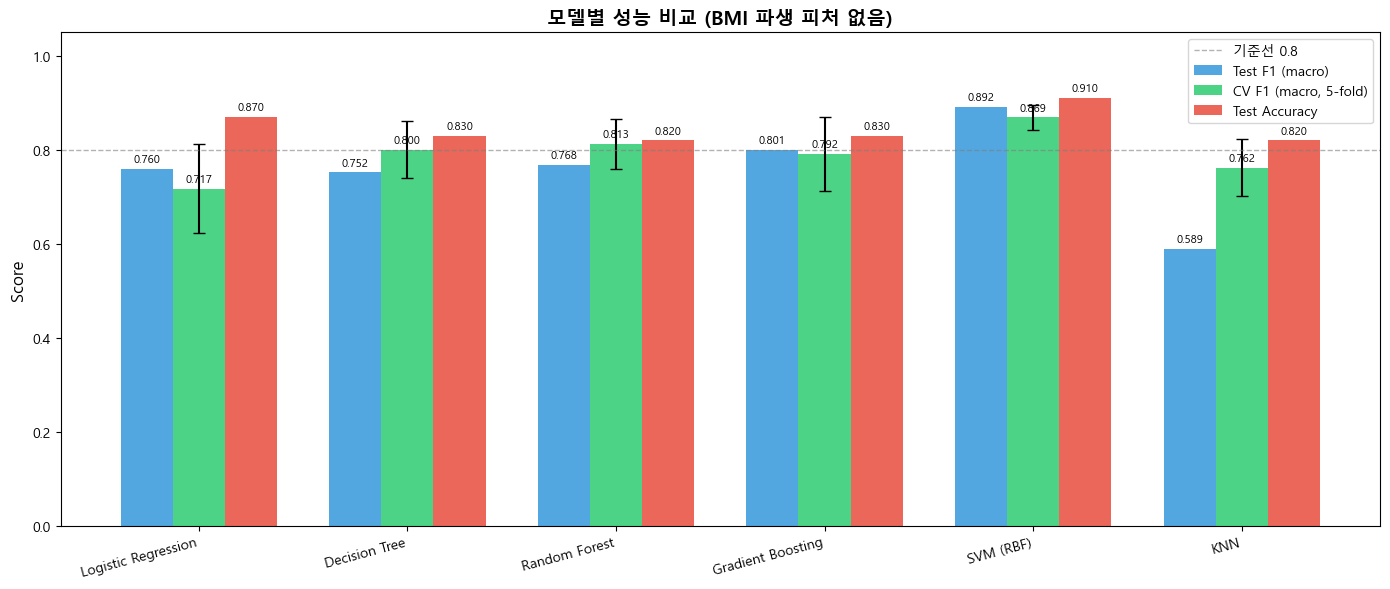

저장: 04_model_comparison.png


In [8]:
# --- [차트 4] 모델별 성능 비교 막대차트 ---
names      = list(results.keys())
test_f1m   = [results[n]['test_f1_macro'] for n in names]
cv_f1m     = [results[n]['cv_f1_macro']   for n in names]
cv_f1m_std = [results[n]['cv_f1macro_std'] if 'cv_f1macro_std' in results[n]
              else results[n]['cv_f1_macro_std'] for n in names]
test_acc   = [results[n]['test_acc']      for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - 0.25, test_f1m, 0.25, label='Test F1 (macro)',       color='#3498db', alpha=0.85)
b2 = ax.bar(x,         cv_f1m,   0.25, label='CV F1 (macro, 5-fold)', color='#2ecc71', alpha=0.85,
            yerr=cv_f1m_std, capsize=4, error_kw={'elinewidth':1.5})
b3 = ax.bar(x + 0.25, test_acc,  0.25, label='Test Accuracy',         color='#e74c3c', alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='기준선 0.8')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('모델별 성능 비교 (BMI 파생 피처 없음)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUT}04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_model_comparison.png')

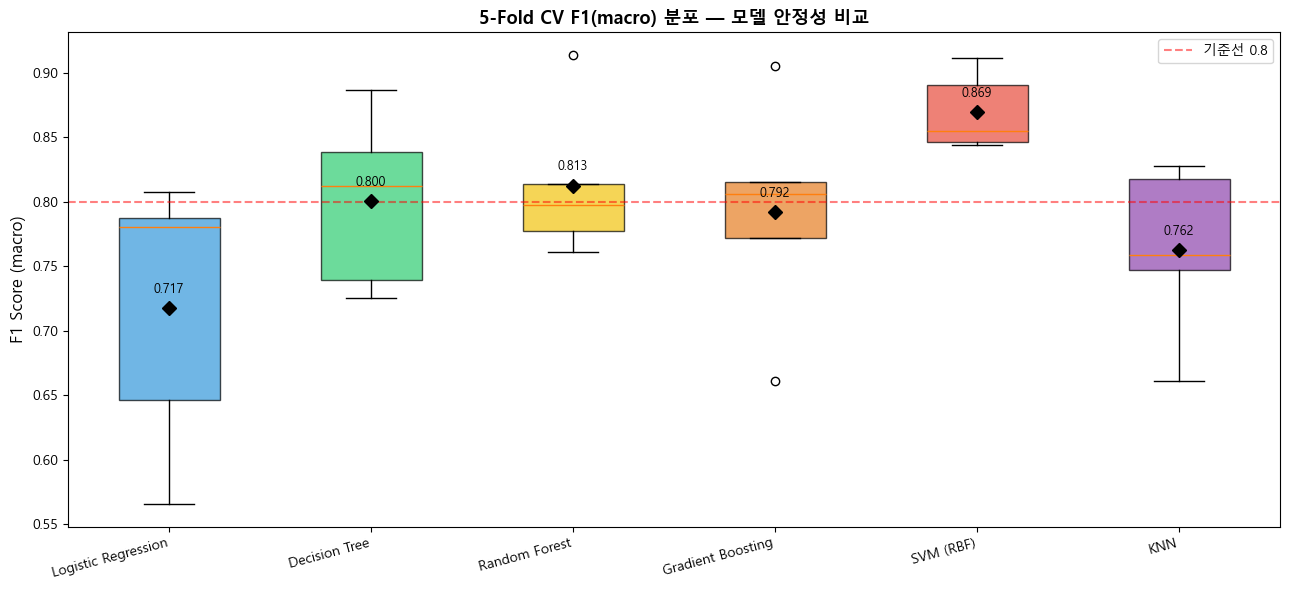

저장: 05_cv_scores.png


In [9]:
# --- [차트 5] 5-Fold CV 점수 분포 박스플롯 ---
fig, ax = plt.subplots(figsize=(13, 6))

cv_data  = [results[n]['cv_raw']['test_f1_macro'] for n in names]
bp = ax.boxplot(cv_data, labels=names, patch_artist=True, notch=False)

box_colors = ['#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 각 모델 평균값 표시
for i, d in enumerate(cv_data, 1):
    ax.plot(i, np.mean(d), 'D', color='black', markersize=7, zorder=5)
    ax.text(i, np.mean(d)+0.012, f'{np.mean(d):.3f}', ha='center', fontsize=9)

ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='기준선 0.8')
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title('5-Fold CV F1(macro) 분포 — 모델 안정성 비교', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}05_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 05_cv_scores.png')

## 6. 최적 모델 성능 분석

In [10]:
# CV F1 macro 기준 최적 모델 선택
best_name = max(results, key=lambda n: results[n]['cv_f1_macro'])
best = results[best_name]

print(f'=== 최적 모델: {best_name} ===')
print(f'Test Accuracy:       {best["test_acc"]:.4f}')
print(f'Test F1 (macro):     {best["test_f1_macro"]:.4f}')
print(f'Test F1 (weighted):  {best["test_f1_w"]:.4f}')
print(f'CV F1 (macro, mean): {best["cv_f1_macro"]:.4f} ± {best["cv_f1_macro_std"]:.4f}')
print()
print('--- Classification Report ---')
print(classification_report(y_test, best['y_pred'], target_names=LABEL_NAMES))

=== 최적 모델: SVM (RBF) ===
Test Accuracy:       0.9100
Test F1 (macro):     0.8918
Test F1 (weighted):  0.9101
CV F1 (macro, mean): 0.8692 ± 0.0269

--- Classification Report ---
                 precision    recall  f1-score   support

 Extremely Weak       1.00      1.00      1.00         3
           Weak       0.67      1.00      0.80         4
         Normal       0.91      0.71      0.80        14
     Overweight       0.81      0.93      0.87        14
        Obesity       0.92      0.92      0.92        26
Extreme Obesity       0.97      0.95      0.96        39

       accuracy                           0.91       100
      macro avg       0.88      0.92      0.89       100
   weighted avg       0.92      0.91      0.91       100



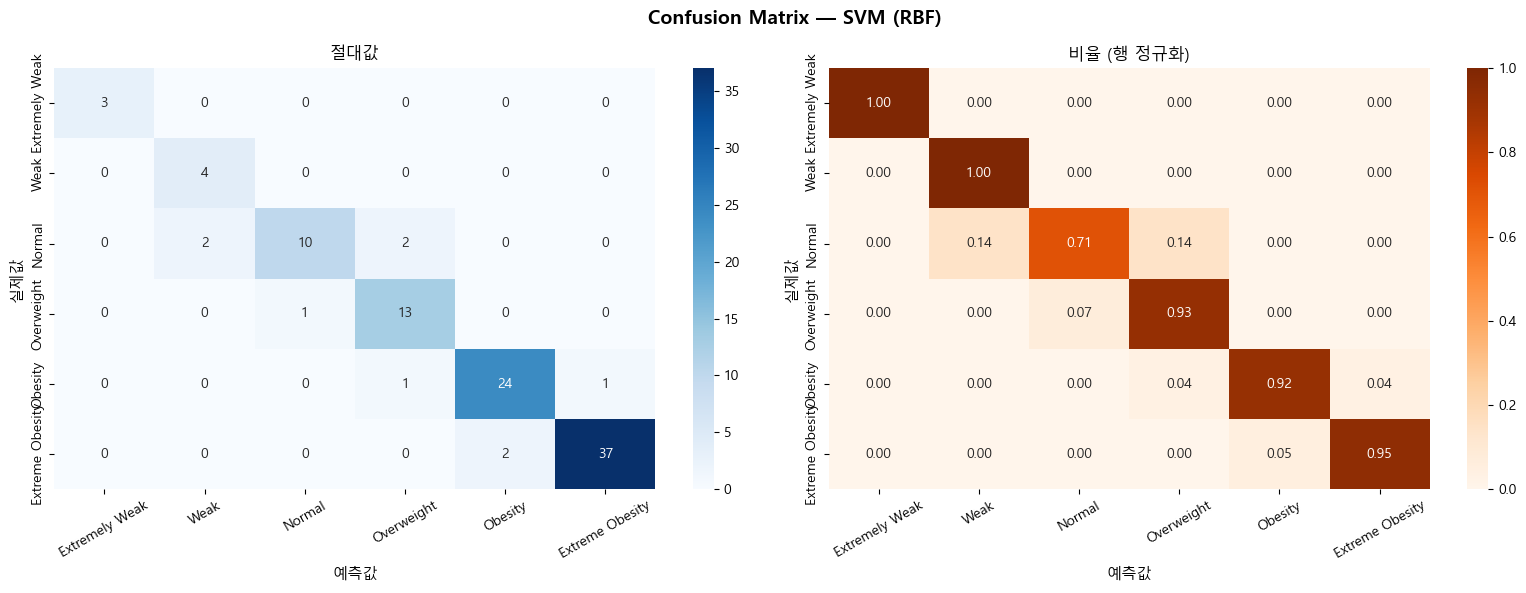

저장: 06_confusion_matrix.png


In [11]:
# --- [차트 6] Confusion Matrix ---
cm = confusion_matrix(y_test, best['y_pred'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # 행 정규화

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')

# 절대값
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title('절대값', fontsize=12)
axes[0].set_xlabel('예측값', fontsize=11)
axes[0].set_ylabel('실제값', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# 비율 (정규화)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('비율 (행 정규화)', fontsize=12)
axes[1].set_xlabel('예측값', fontsize=11)
axes[1].set_ylabel('실제값', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{OUT}06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 06_confusion_matrix.png')

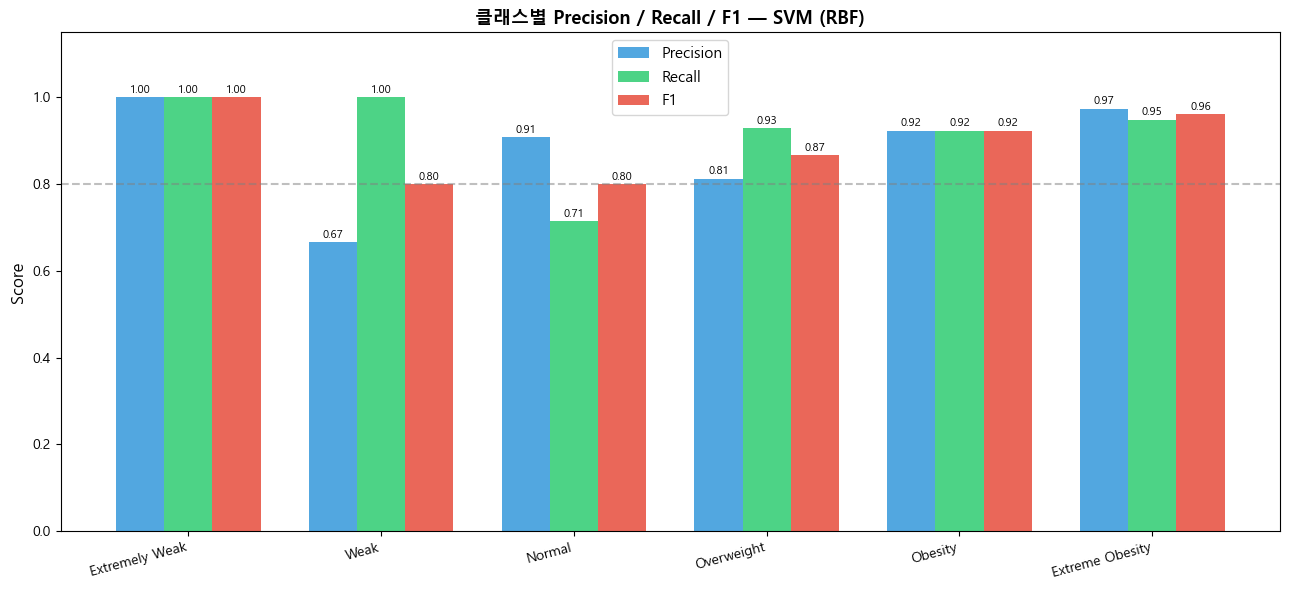

저장: 07_class_metrics.png


In [12]:
# --- [차트 7] 클래스별 Precision / Recall / F1 ---
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, best['y_pred'], labels=list(range(6))
)

x = np.arange(6)
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - 0.25, prec, 0.25, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x,        rec,  0.25, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x + 0.25, f1,   0.25, label='F1',        color='#e74c3c', alpha=0.85)

for i in range(6):
    for offset, val in zip([-0.25, 0, 0.25], [prec[i], rec[i], f1[i]]):
        ax.text(i+offset, val+0.01, f'{val:.2f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'클래스별 Precision / Recall / F1 — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUT}07_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_class_metrics.png')

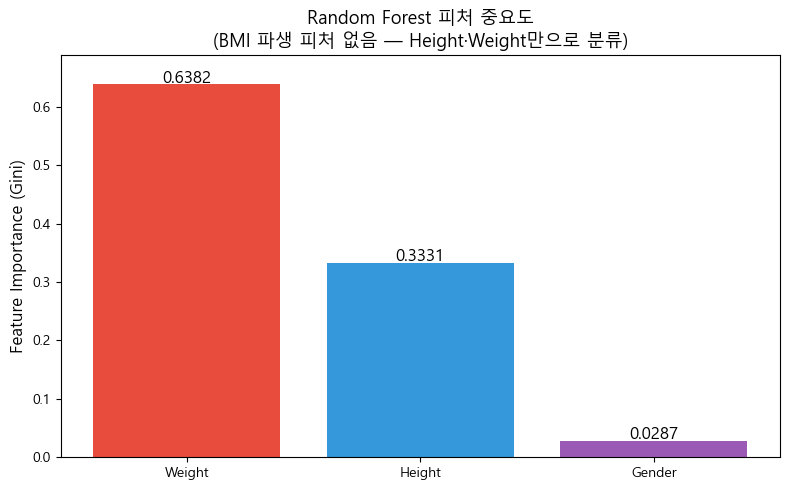

저장: 08_feature_importance.png

피처 중요도 해석:
  Weight: 0.6382 (63.8%)
  Height: 0.3331 (33.3%)
  Gender: 0.0287 (2.9%)


In [13]:
# --- [차트 8] 피처 중요도 (Random Forest 기준) ---
rf = results['Random Forest']['model']
importances = rf.feature_importances_
feature_names = ['Gender', 'Height', 'Weight']
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#9b59b6','#3498db','#e74c3c']
bars = ax.bar(
    [feature_names[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[bar_colors[i] for i in sorted_idx]
)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.4f}', ha='center', fontsize=12)
ax.set_ylabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest 피처 중요도\n(BMI 파생 피처 없음 — Height·Weight만으로 분류)', fontsize=13)
ax.set_ylim(0, max(importances) + 0.05)
plt.tight_layout()
plt.savefig(f'{OUT}08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 08_feature_importance.png')
print()
print('피처 중요도 해석:')
for i in sorted_idx:
    print(f'  {feature_names[i]}: {importances[i]:.4f} ({importances[i]*100:.1f}%)')

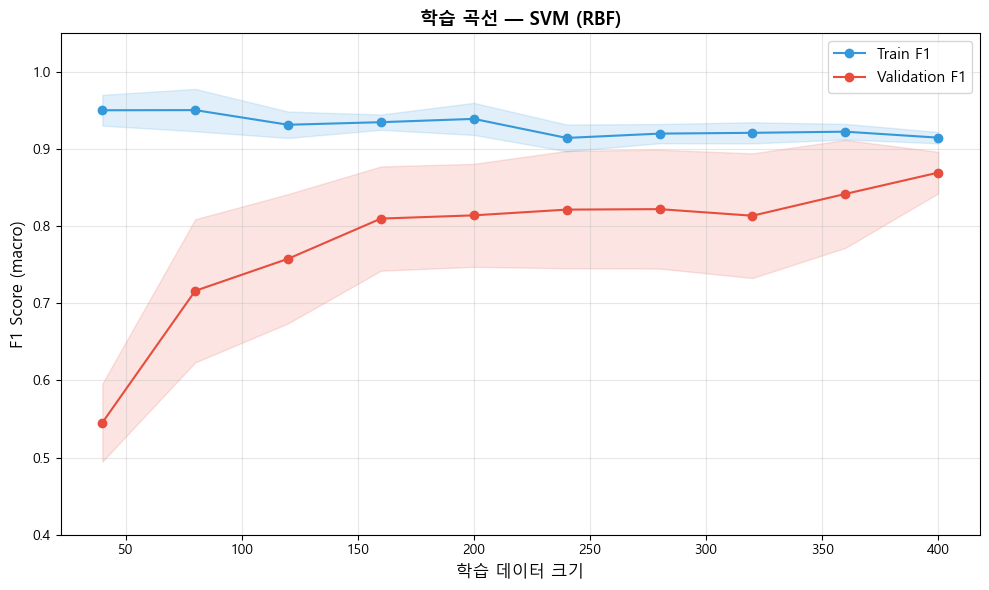

저장: 09_learning_curve.png


In [14]:
# --- [차트 9] 학습 곡선 (최적 모델) ---
best_model = best['model']
Xall_fit = scaler.transform(X) if best['use_scale'] else X

train_sizes, train_scores, val_scores = learning_curve(
    best_model, Xall_fit, y,
    cv=cv, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Train F1')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation F1')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#e74c3c')

ax.set_xlabel('학습 데이터 크기', fontsize=12)
ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title(f'학습 곡선 — {best_name}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.4, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT}09_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 09_learning_curve.png')

## 7. 모델 저장

In [15]:
save_obj = {
    'model_name':    best_name,
    'model':         best['model'],
    'scaler':        scaler if best['use_scale'] else None,
    'label_encoder': le,
    'features':      ['Gender_enc', 'Height', 'Weight'],
    'label_names':   LABEL_NAMES,
    'test_f1_macro': best['test_f1_macro'],
    'cv_f1_macro':   best['cv_f1_macro'],
}
with open('../bmi_model.pkl', 'wb') as f:
    pickle.dump(save_obj, f)

print('=== 최종 결과 ===')
print(f'최적 모델:           {best_name}')
print(f'Test Accuracy:       {best["test_acc"]:.4f}')
print(f'Test F1 (macro):     {best["test_f1_macro"]:.4f}')
print(f'CV F1 (macro):       {best["cv_f1_macro"]:.4f} ± {best["cv_f1_macro_std"]:.4f}')
print()
print('저장 완료: bmi_model.pkl')
print('출력 PNG: output/ 디렉토리 (01~09번)')

=== 최종 결과 ===
최적 모델:           SVM (RBF)
Test Accuracy:       0.9100
Test F1 (macro):     0.8918
CV F1 (macro):       0.8692 ± 0.0269

저장 완료: bmi_model.pkl
출력 PNG: output/ 디렉토리 (01~09번)
